In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import monk_common as mc
import seaborn as sns

In [3]:

def plot_data(X, y):
    # X: array o dataframe one-hot (n_samples, n_features)
    # y: labels 0/1

    X_np = X.values if hasattr(X, "values") else np.asarray(X)
    y_np = y.values.ravel() if hasattr(y, "values") else np.asarray(y).ravel()

    # =====================
    # PCA 2D
    # =====================
    pca = PCA(n_components=2, random_state=42)
    Z_pca = pca.fit_transform(X_np)

    plt.figure()
    plt.scatter(Z_pca[y_np == 0, 0], Z_pca[y_np == 0, 1], c="red", label="Class 0", s=20, alpha=1)
    plt.scatter(Z_pca[y_np == 1, 0], Z_pca[y_np == 1, 1], c="green", label="Class 1", s=20, alpha=0.1)

    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title("MONK – PCA 2D")
    plt.legend()
    plt.grid(True)
    plt.show()

    # =====================
    # t-SNE 2D
    # =====================
    tsne = TSNE(
        n_components=2,
        random_state=42,
        init="pca",
        learning_rate="auto",
        perplexity=30
    )
    Z_tsne = tsne.fit_transform(X_np)

    plt.figure()
    plt.scatter(Z_tsne[y_np==0,0], Z_tsne[y_np==0,1], c="red",   marker="o", s=40, alpha=1.0, label="Class 0")
    plt.scatter(Z_tsne[y_np==1,0], Z_tsne[y_np==1,1], c="green", marker="o", s=30, alpha=0.1, label="Class 1")

    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.title("MONK – t-SNE 2D")
    plt.legend()
    plt.grid(True)
    plt.show()



<hr/>

<h3>Monk 1</hr>

In [4]:
monk_1_TR_orig, monk_1_TS_orig = mc.load_set(1)
monk_1_TR_features, monk_1_TR_labels = mc.split_and_prepare_dataset(monk_1_TR_orig)
monk_1_TS_features, monk_1_TS_labels = mc.split_and_prepare_dataset(monk_1_TS_orig)
features_names = monk_1_TR_orig.drop(columns=['class', 'id']).columns
mc.dataset_introspection(monk_1_TR_orig, monk_1_TS_orig)

,Property,Training,Test
0,Number of samples,124,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 62","class 0 = 216, class 1 = 216"


In [5]:
monk_1_TR_features, monk_1_TR_labels = mc.split_and_prepare_dataset(monk_1_TR_orig)
monk_1_TS_features, monk_1_TS_labels = mc.split_and_prepare_dataset(monk_1_TS_orig)

In [6]:
monk_1_TR_features.head()

,a1_1,a1_2,a1_3,a2_1,a2_2,a2_3,a3_1,a3_2,a4_1,a4_2,a4_3,a5_1,a5_2,a5_3,a5_4,a6_1,a6_2
0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0
1,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1
2,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0
3,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1
4,1,0,0,1,0,0,0,1,1,0,0,0,1,0,0,1,0


In [7]:
monk_1_TS_features.head()

,a1_1,a1_2,a1_3,a2_1,a2_2,a2_3,a3_1,a3_2,a4_1,a4_2,a4_3,a5_1,a5_2,a5_3,a5_4,a6_1,a6_2
0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0
1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,1
2,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0
3,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1
4,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0


In [8]:
monk_1_TS_features.shape

(432, 17)

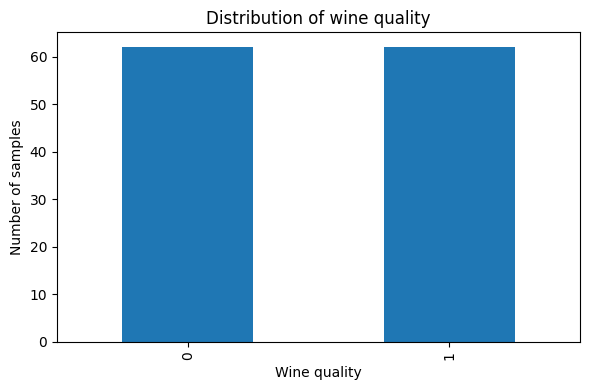

In [9]:
plt.figure(figsize=(6,4))
monk_1_TR_orig['class'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Wine quality')
plt.ylabel('Number of samples')
plt.title('Distribution of wine quality')
plt.tight_layout()
plt.show()

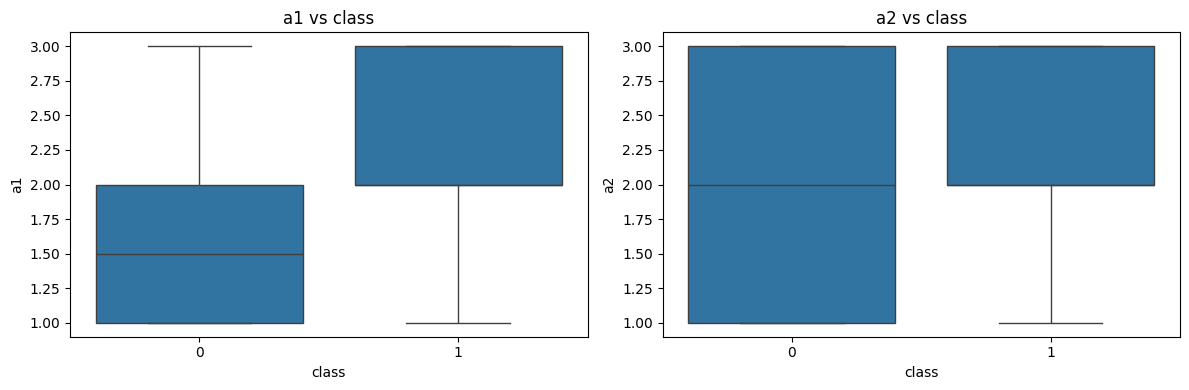

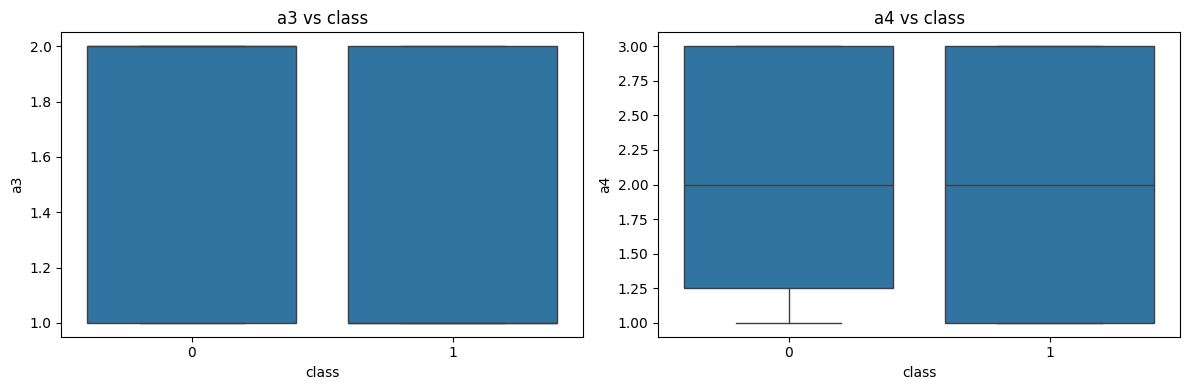

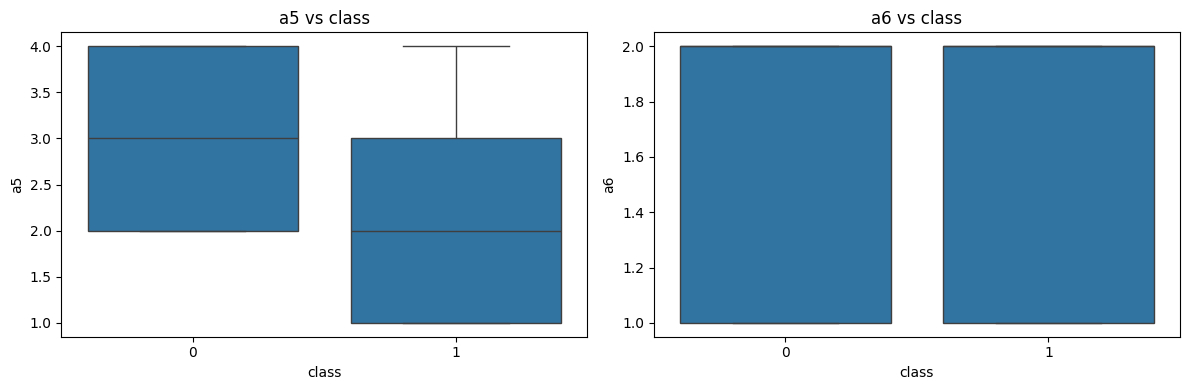

In [10]:
def boxplot_features_pairwise(df, features, target='class'):
    # scorre le feature due a due
    for i in range(0, len(features), 2):

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

        # prima feature della coppia
        f1 = features[i]
        sns.boxplot(
            x=target,
            y=f1,
            data=df,
            ax=axes[0]
        )
        axes[0].set_title(f'{f1} vs {target}')

        # seconda feature (se esiste)
        if i + 1 < len(features):
            f2 = features[i + 1]
            sns.boxplot(
                x=target,
                y=f2,
                data=df,
                ax=axes[1]
            )
            axes[1].set_title(f'{f2} vs {target}')
        else:
            # se il numero di feature è dispari, nascondi il secondo subplot
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()


boxplot_features_pairwise(monk_1_TR_orig, features_names)

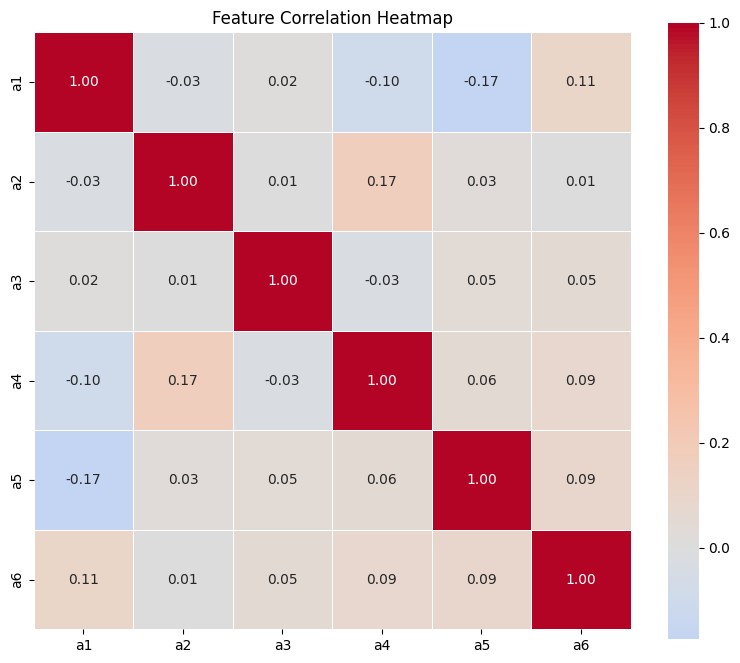

In [11]:
# matrice di correlazione
corr = monk_1_TR_orig[features_names].corr()

plt.figure(figsize=(8, 8))
sns.heatmap(
    corr,
    annot=True,          # <-- mostra i valori
    fmt=".2f",           # <-- 2 cifre decimali (perfetto)
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

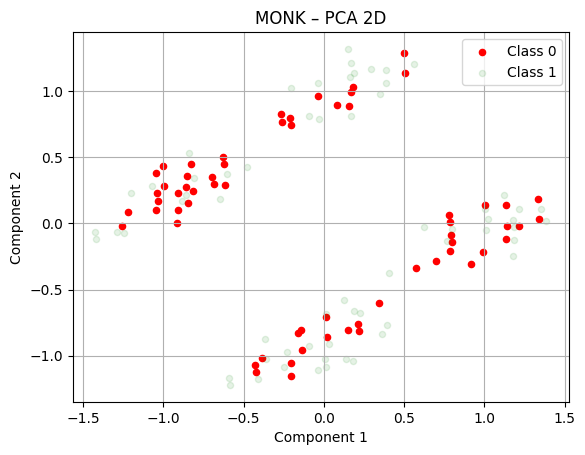

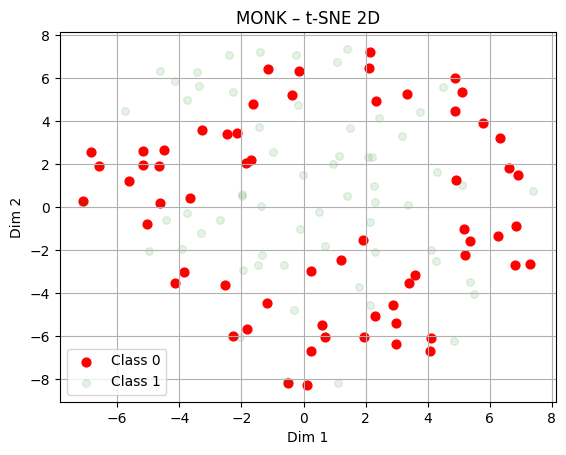

In [12]:
plot_data(monk_1_TR_features, monk_1_TR_labels)

In [13]:
print("n_samples:", monk_1_TS_features.shape[0])
print("n_unique_rows:", np.unique(np.asarray(monk_1_TS_features), axis=0).shape[0])


y_np = np.asarray(monk_1_TS_labels).ravel()
print("dtype:", y_np.dtype)
print("unique:", np.unique(y_np, return_counts=True))
print(np.unique(y_np, return_counts=True))

n_samples: 432
n_unique_rows: 432
dtype: int64
unique: (array([0, 1]), array([216, 216]))
(array([0, 1]), array([216, 216]))


<h3>Monk 2</h2>

In [14]:
monk_2_TR_orig, monk_2_TS_orig = mc.load_set(2)
monk_2_TR_features, monk_2_TR_labels = mc.split_and_prepare_dataset(monk_2_TR_orig)
monk_2_TS_features, monk_2_TS_labels = mc.split_and_prepare_dataset(monk_2_TS_orig)
mc.dataset_introspection(monk_2_TR_orig, monk_2_TS_orig)

,Property,Training,Test
0,Number of samples,169,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 105, class 1 = 64","class 0 = 290, class 1 = 142"


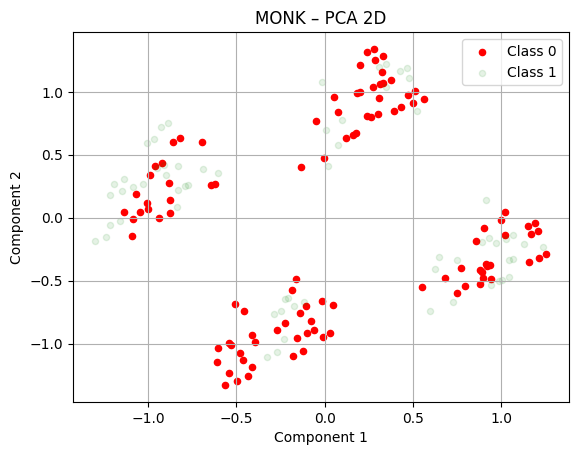

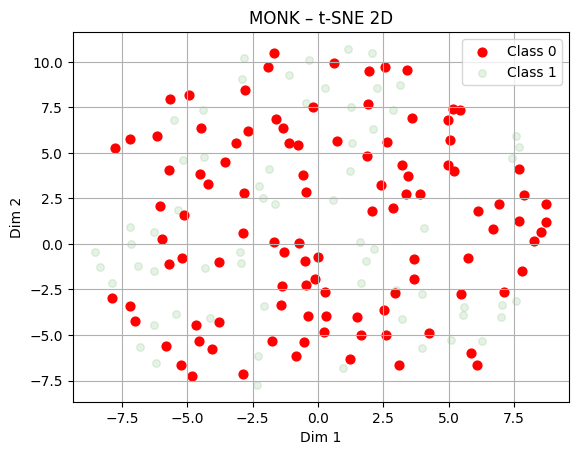

In [15]:
plot_data(monk_2_TR_features, monk_2_TR_labels)

<h3>Monk 3</h2>

In [16]:
monk_3_TR_orig, monk_3_TS_orig = mc.load_set(3)
monk_3_TR_features, monk_3_TR_labels = mc.split_and_prepare_dataset(monk_3_TR_orig)
monk_3_TS_features, monk_3_TS_labels = mc.split_and_prepare_dataset(monk_3_TS_orig)
mc.dataset_introspection(monk_3_TR_orig, monk_3_TS_orig)

,Property,Training,Test
0,Number of samples,122,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 60","class 0 = 204, class 1 = 228"


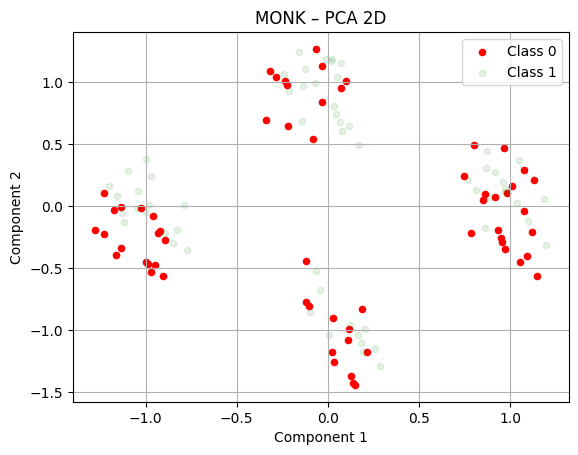

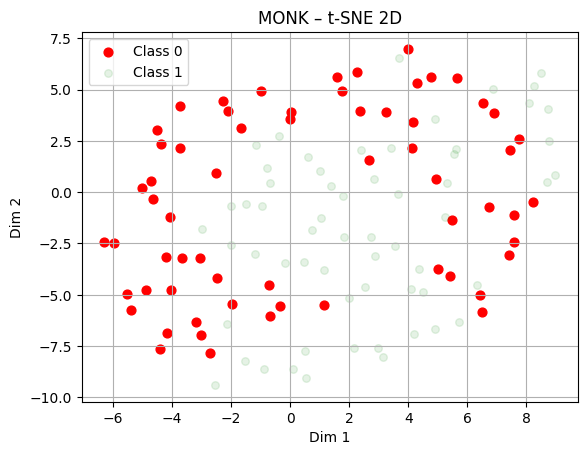

In [17]:
plot_data(monk_3_TR_features, monk_3_TR_labels)

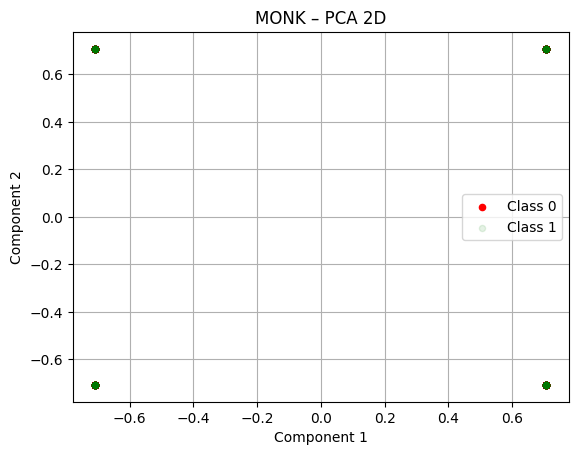

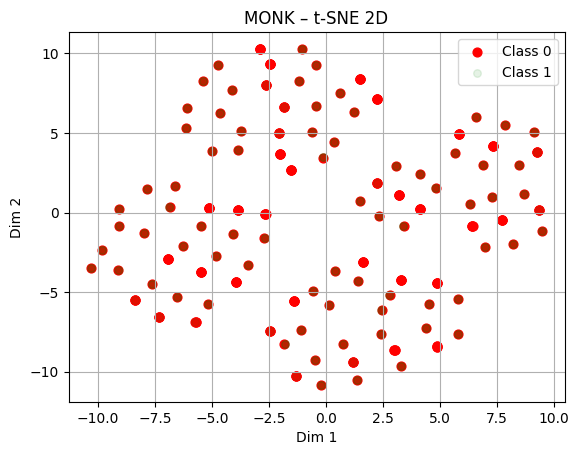

In [18]:
plot_data(monk_3_TS_features, monk_3_TS_labels)